In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import InputLayer,Dense,Flatten,Dropout,Conv2D,MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
(xtrain,ytrain),(xtest,ytest)=mnist.load_data()

In [5]:
xtrain.shape

(60000, 28, 28)

In [6]:
ytrain.shape

(60000,)

In [7]:
xtest.shape

(10000, 28, 28)

In [8]:
ytest.shape

(10000,)

In [9]:
xtrain[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [10]:
ytrain[0]

np.uint8(5)

In [12]:
np.unique(ytrain)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [79]:
model=Sequential([
InputLayer(shape=(28,28,1)),
Conv2D(48,(4,4),activation="relu"),
MaxPooling2D((2,2)),
Conv2D(24,(3,3),activation="relu"),
MaxPooling2D((2,2)),
Conv2D(12,(2,2),activation="relu"),
MaxPooling2D((2,2)),
Flatten(),
Dense(50,activation="relu"),
Dropout(0.2),
Dense(10,activation='softmax')
])

In [80]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 25, 25, 48)          │             816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 12, 12, 48)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 10, 10, 24)          │          10,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 5, 5, 24)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 4, 4, 12)            │           1,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 2, 2, 12)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 50)                  │           2,450 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,332 (59.89 KB)

 Trainable params: 15,332 (59.89 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [82]:
history=model.fit(xtrain,ytrain,batch_size=100,epochs=10,validation_data=(xtest,ytest),callbacks=EarlyStopping(patience=5))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6873 - loss: 1.0813 - val_accuracy: 0.9228 - val_loss: 0.2533
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9261 - loss: 0.2451 - val_accuracy: 0.9550 - val_loss: 0.1350
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9500 - loss: 0.1672 - val_accuracy: 0.9730 - val_loss: 0.0897
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9601 - loss: 0.1345 - val_accuracy: 0.9775 - val_loss: 0.0759
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9649 - loss: 0.1190 - val_accuracy: 0.9745 - val_loss: 0.0849
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9694 - loss: 0.0994 - val_accuracy: 0.9762 - val_loss: 0.0822
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9732 - loss: 0.0913 - val_accuracy: 0.9769 - val_loss: 0.0754
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9751 - loss: 0.0825 - val_accu

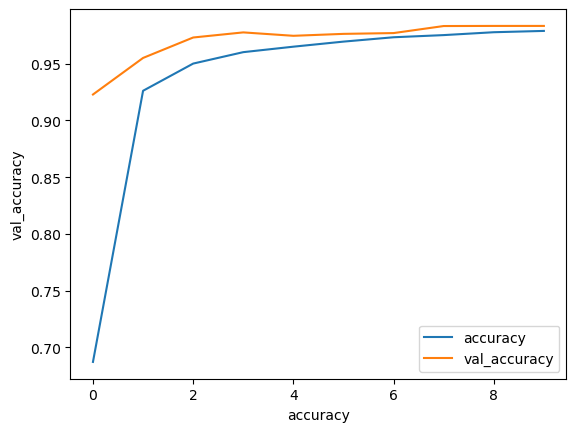

In [83]:
plt.plot(history.history["accuracy"],label="accuracy")
plt.plot(history.history["val_accuracy"],label="val_accuracy")
plt.xlabel("accuracy")
plt.ylabel("val_accuracy")
plt.legend()
plt.show()

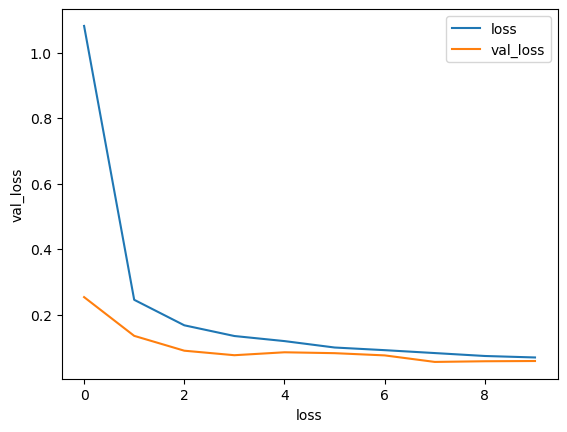

In [84]:
plt.plot(history.history["loss"],label='loss')
plt.plot(history.history["val_loss"],label='val_loss')
plt.xlabel("loss")
plt.ylabel("val_loss")
plt.legend()
plt.show()

In [85]:
ypred=model.predict(xtest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [86]:
ypred

array([[1.1155668e-17, 6.5778600e-14, 2.6448363e-10, ..., 1.0000000e+00,
        7.5430824e-13, 4.0061254e-16],
       [1.4760303e-08, 1.6497408e-07, 9.9999988e-01, ..., 3.6471019e-13,
        2.1667590e-09, 1.0562595e-14],
       [2.3042814e-08, 9.9999499e-01, 5.8699630e-08, ..., 2.8056277e-06,
        8.4318657e-07, 1.2569183e-08],
       ...,
       [3.9752706e-13, 3.9763987e-10, 8.5950163e-09, ..., 1.9853966e-08,
        4.7724780e-07, 7.9879246e-05],
       [3.3349941e-08, 1.3029726e-15, 6.9220918e-09, ..., 1.8621942e-07,
        7.5151787e-05, 4.6197303e-07],
       [2.7417943e-07, 7.3954108e-14, 1.5259592e-06, ..., 8.8353099e-14,
        6.5982198e-07, 1.5179238e-16]], shape=(10000, 10), dtype=float32)

In [87]:
ypred.shape

(10000, 10)

In [88]:
ypred=np.argmax(ypred,axis=1)

In [89]:
ypred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

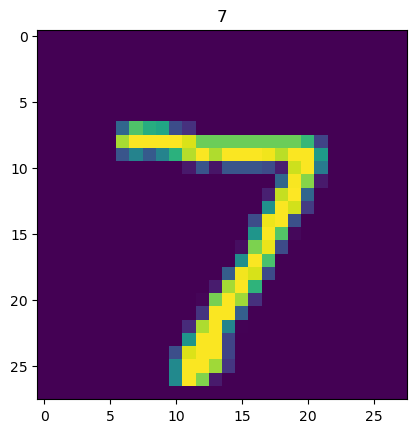

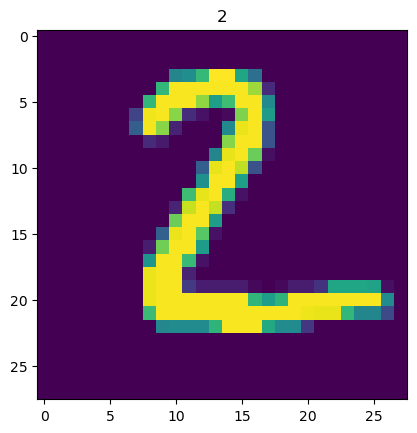

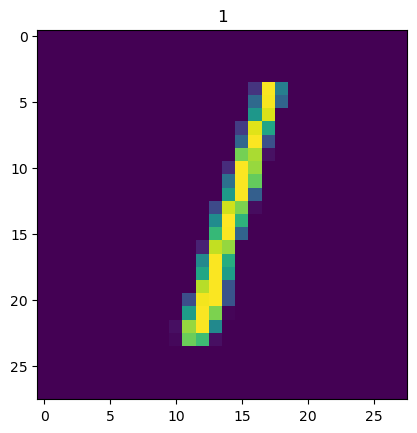

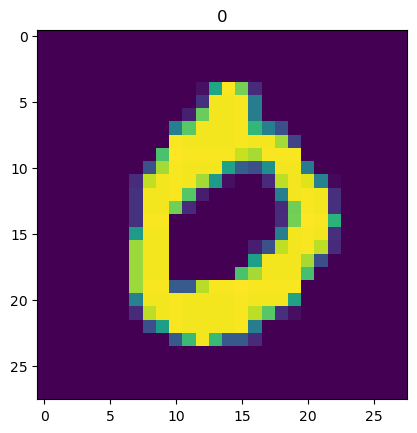

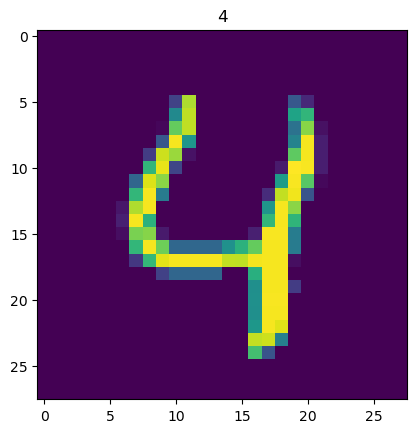

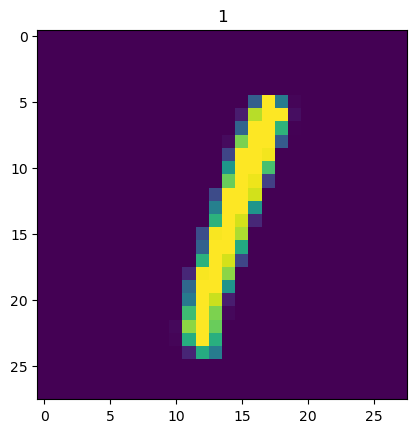

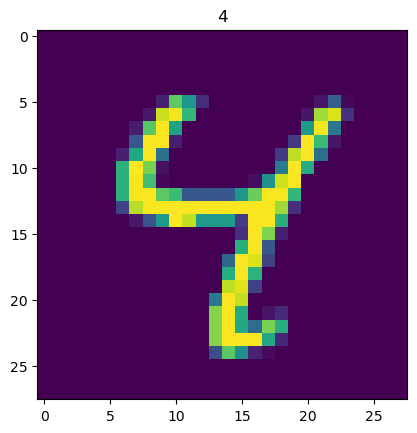

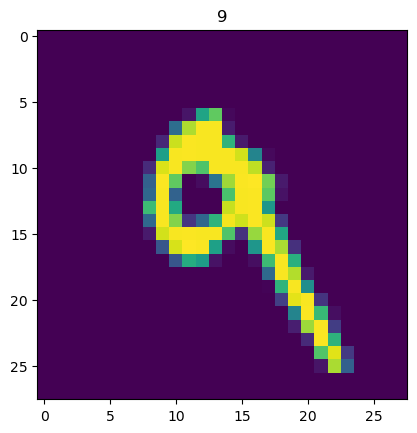

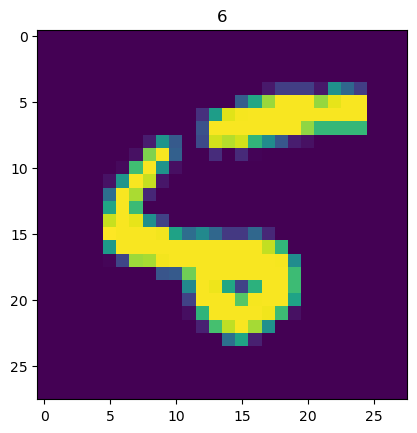

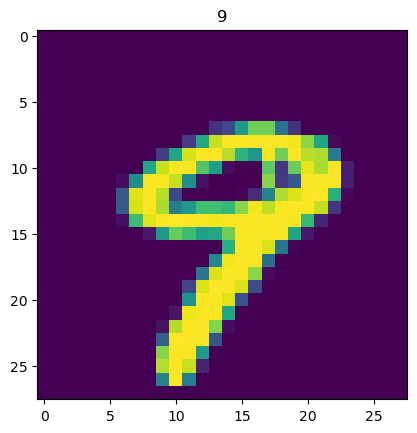

In [90]:
for i in range(10):
    plt.imshow(xtest[i])
    plt.title(ypred[i])
    plt.show()

In [65]:
model.evaluate(xtest,ytest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0755


[0.0754721388220787, 0.977400004863739]